In [10]:
!pip install squarify

In [18]:
import pandas as pd
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import squarify

In [22]:
data = pd.read_csv("../../datasets/Arsenal_2025_26_Standard_Stats.csv")
data.head()

,Player,Pos,MP,Starts,Min,Gls,Ast,G+A,G-PK,PK,...,Ast.1,G+A.1,G-PK.1,G+A-PK,xG.1,xAG.1,xG+xAG,npxG.1,npxG+xAG.1,Matches
0,David Raya,GK,21,21,"1,890",0.0,0.0,0.0,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Matches
1,Martín Zubimendi,MF,21,20,"1,769",3.0,1.0,4.0,3.0,0.0,...,0.05,0.20,0.15,0.20,0.10,0.05,0.15,0.10,0.15,Matches
2,Declan Rice,MF,20,19,"1,696",4.0,3.0,7.0,4.0,0.0,...,0.16,0.37,0.21,0.37,0.13,0.18,0.32,0.13,0.32,Matches
3,Jurriën Timber,DF,20,18,"1,641",2.0,3.0,5.0,2.0,0.0,...,0.16,0.27,0.11,0.27,0.22,0.06,0.28,0.22,0.28,Matches
4,Bukayo Saka,FW,19,16,"1,422",4.0,3.0,7.0,3.0,1.0,...,0.19,0.44,0.19,0.38,0.34,0.31,0.65,0.29,0.60,Matches


The dataset is the standard stats of the Arsenal's 2025/2026 squad as of 10/01/2025. For each player, the dataframe has match and minutes played, goals, assists, card data and expected goals.

We can visualize the threats to know where they come from and who the Arsenal depends most for goals and assists.

The steps to create the treemap are as follows:
 - Create a new dataframe that has only the players that have scored.
 - Create a colormap using matplotlib to assign each player a color acordding to how many goals they have scored.
 - Set up a new rectangular plot for the treemap
 - Plot data and title
 - Display the plot with no axes.

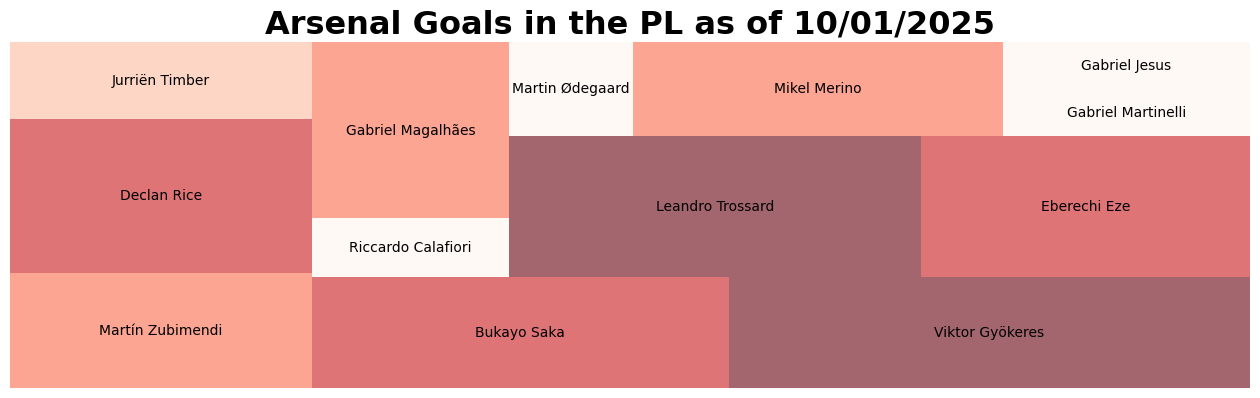

In [32]:
# New dataframe with players who have > 0 goals
data_goals = data[data["Gls"]>0]

# Scale goals numbers between the min and max, then assign this scale to our values
norm = matplotlib.colors.Normalize(vmin=min(data_goals.Gls), vmax=max(data_goals.Gls))
colors = [matplotlib.cm.Reds(norm(value)) for value in data_goals.Gls]

# Create and resize the plot 
fig = plt.gcf()
ax = fig.add_subplot()
fig.set_size_inches(16, 4.5)

# Use squarify to plot the data, lable it and add colors. Add an alpha layer for black labels 
squarify.plot(label=data_goals.Player,sizes=data_goals.Gls, color = colors, alpha=.6)
plt.title("Arsenal Goals in the PL as of 10/01/2025",fontsize=23,fontweight="bold")

# Remove axes and display 
plt.axis('off')
plt.show()

Next, is the treemap for assists:

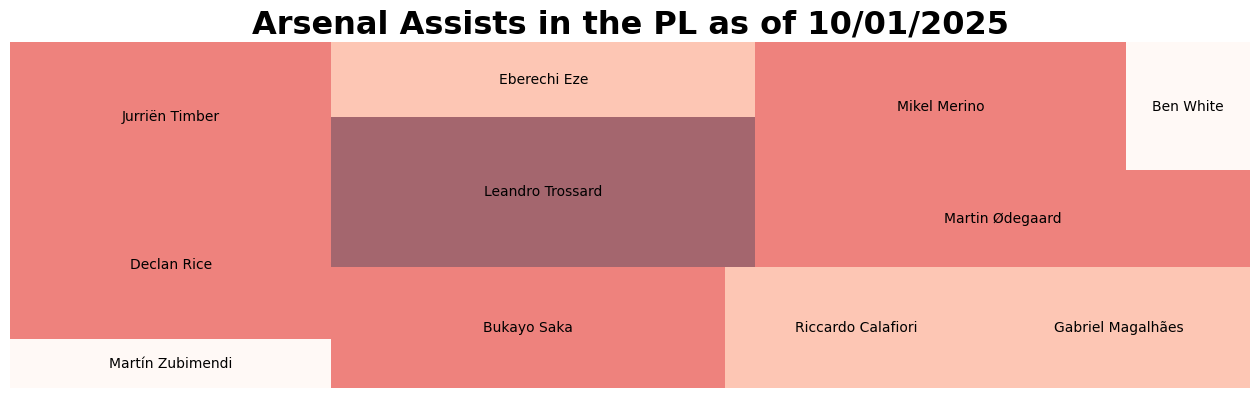

In [31]:
data_assists = data[data["Ast"]>0]

norm = matplotlib.colors.Normalize(vmin=min(data_assists.Ast), vmax=max(data_assists.Ast))
colors = [matplotlib.cm.Reds(norm(value)) for value in data_assists.Ast]

fig = matplotlib.pyplot.gcf()
fig.set_size_inches(16, 4.5)

fig = plt.gcf()
fig.set_size_inches(16, 4.5)

squarify.plot(label=data_assists.Player,sizes=data_assists.Ast, color = colors, alpha=.6)
plt.title("Arsenal Assists in the PL as of 10/01/2025",fontsize=23,fontweight="bold")

plt.axis('off')
plt.show()